# 01 — Data Exploration

**Goal:** Load the 2022 World Cup event data from StatsBomb Open Data, understand its structure, and verify that we have everything needed to build passing networks.

**Data source:** StatsBomb Open Data — Competition ID 43, Season ID 106 (FIFA World Cup 2022)

**Key tables:**
- `matches` — one row per match (64 total)
- `events` — one row per on-ball event within a match
- `lineups` — squad lists with positions per match

**What we verify here:**
1. All 64 matches are present
2. The `Pass` event type contains passer, recipient, and x/y coordinates
3. Completed vs. incomplete pass distribution
4. Set-piece pass volume (to inform the open-play filter decision)
5. Coverage of player position data (for GK involvement feature)

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsbombpy import sb
from data_loader import (
    load_matches, load_events, extract_passes, load_lineups,
    COMPETITION_ID, SEASON_ID, QUARTERFINALISTS
)

DATA_DIR = Path('../data')
RAW_DIR  = DATA_DIR / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

## 1. Match list

In [2]:
matches, team_labels = load_matches(cache_path=RAW_DIR / 'matches.csv')

print(f"Matches loaded: {len(matches)}")
print(f"Columns: {list(matches.columns)}")
matches[['match_id','home_team','away_team','home_score','away_score',
          'stage_label','match_date']].head(10)

Matches loaded: 64
Columns: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_manager_country_id', 'away

,match_id,home_team,away_team,home_score,away_score,stage_label,match_date
0,3857276,Canada,Morocco,1,2,group,2022-12-01
1,3857271,England,Iran,6,2,group,2022-11-21
2,3857296,Croatia,Belgium,0,0,group,2022-12-01
3,3857274,Netherlands,Ecuador,1,1,group,2022-11-25
4,3857255,Japan,Spain,2,1,group,2022-12-01
5,3857272,England,United States,0,0,group,2022-11-25
6,3857278,Iran,United States,0,1,group,2022-11-29
7,3857277,Morocco,Croatia,0,0,group,2022-11-23
8,3857273,Wales,Iran,0,2,group,2022-11-25
9,3857275,Tunisia,France,1,0,group,2022-11-30


In [3]:
# Matches per stage
if 'stage_label' in matches.columns:
    print(matches['stage_label'].value_counts())
else:
    print(matches['match_week'].value_counts())

stage_label
group              48
R16                 8
QF                  4
SF                  2
Final               1
3rd Place Final     1
Name: count, dtype: int64


In [4]:
print("\nQuarterfinalist flag:")
print(team_labels.sort_values('reached_quarterfinal', ascending=False).to_string(index=False))


Quarterfinalist flag:
         team  reached_quarterfinal
     Portugal                     1
  Netherlands                     1
      Morocco                     1
       France                     1
       Brazil                     1
    Argentina                     1
      Croatia                     1
      England                     1
    Australia                     0
       Serbia                     0
   Costa Rica                     0
       Poland                     0
       Mexico                     0
      Germany                     0
      Uruguay                     0
      Denmark                     0
        Qatar                     0
 Saudi Arabia                     0
       Canada                     0
      Senegal                     0
        Ghana                     0
     Cameroon                     0
  Switzerland                     0
      Tunisia                     0
        Wales                     0
United States                     0
     

## 2. Inspect one match — event structure

In [5]:
sample_match_id = int(matches['match_id'].iloc[0])
print(f"Loading events for match_id={sample_match_id} "
      f"({matches.loc[matches.match_id==sample_match_id,'home_team'].values[0]} vs "
      f"{matches.loc[matches.match_id==sample_match_id,'away_team'].values[0]})")

events = load_events(sample_match_id, cache_dir=RAW_DIR / 'events')
print(f"Total events: {len(events)}")
print("\nEvent type counts:")
print(events['type'].value_counts().head(15))

Loading events for match_id=3857276 (Canada vs Morocco)
Total events: 3388

Event type counts:
type
Pass              955
Ball Receipt*     868
Carry             782
Pressure          289
Ball Recovery      93
Duel               63
Clearance          41
Dribble            39
Miscontrol         32
Foul Committed     31
Foul Won           31
Block              27
Interception       23
Dispossessed       23
Dribbled Past      23
Name: count, dtype: int64


In [6]:
# Inspect raw pass columns
raw_passes = events[events['type'] == 'Pass'].copy()
pass_cols = [c for c in raw_passes.columns if 'pass' in c.lower() or c in ('location','player','team','minute')]
print("Pass-related columns available:")
print(pass_cols)
raw_passes[pass_cols].head(3)

Pass-related columns available:
['location', 'minute', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_miscommunication', 'pass_outcome', 'pass_outswinging', 'pass_recipient', 'pass_recipient_id', 'pass_shot_assist', 'pass_switch', 'pass_technique', 'pass_through_ball', 'pass_type', 'player', 'shot_key_pass_id', 'team']


,location,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,...,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,player,shot_key_pass_id,team
6,"[61.0, 40.1]",0,None,3.045886,None,Left Foot,None,None,"[48.5, 41.3]",None,...,Sofyan Amrabat,5234.0,None,None,None,None,Kick Off,Youssef En-Nesyri,None,Morocco
7,"[48.4, 42.5]",0,None,2.396870,None,Right Foot,None,None,"[30.5, 59.0]",None,...,Nayef Aguerd,12149.0,None,None,None,None,None,Sofyan Amrabat,None,Morocco
8,"[30.9, 59.0]",0,None,-1.605051,None,Left Foot,None,None,"[29.8, 26.9]",None,...,Romain Saïss,5219.0,None,None,None,None,None,Nayef Aguerd,None,Morocco


In [7]:
# Completed vs incomplete
outcome_counts = raw_passes['pass_outcome'].fillna('Completed').value_counts()
print("Pass outcomes in this match:")
print(outcome_counts)

Pass outcomes in this match:
pass_outcome
Completed       790
Incomplete      134
Out              21
Pass Offside      7
Unknown           3
Name: count, dtype: int64


In [8]:
# Set-piece type breakdown
if 'pass_type' in raw_passes.columns:
    print("\nPass type distribution (set-pieces vs open play):")
    print(raw_passes['pass_type'].fillna('Open Play').value_counts())


Pass type distribution (set-pieces vs open play):
pass_type
Open Play       793
Recovery         53
Throw-in         43
Free Kick        35
Goal Kick        11
Corner            8
Interception      7
Kick Off          5
Name: count, dtype: int64


## 3. Extract completed passes and verify fields

In [9]:
# All completed passes
all_passes = extract_passes(events, open_play_only=False)
print(f"Completed passes (all):        {len(all_passes)}")

# Open-play completed passes only
op_passes = extract_passes(events, open_play_only=True)
print(f"Completed passes (open play):  {len(op_passes)}")
print(f"Set-piece passes removed:      {len(all_passes) - len(op_passes)} "
      f"({(len(all_passes)-len(op_passes))/len(all_passes)*100:.1f}%)")

Completed passes (all):        790
Completed passes (open play):  714
Set-piece passes removed:      76 (9.6%)


In [10]:
print("\nCleaned pass table columns:")
print(all_passes.columns.tolist())

print("\nMissing values:")
print(all_passes.isnull().sum())

print("\nSample rows:")
all_passes[['player','pass_recipient','x','y','end_x','end_y',
            'is_progressive','is_final_third']].head(8)


Cleaned pass table columns:
['id', 'match_id', 'team', 'player', 'pass_recipient', 'minute', 'period', 'x', 'y', 'end_x', 'end_y', 'is_progressive', 'is_final_third']

Missing values:
id                0
match_id          0
team              0
player            0
pass_recipient    0
minute            0
period            0
x                 0
y                 0
end_x             0
end_y             0
is_progressive    0
is_final_third    0
dtype: int64

Sample rows:


,player,pass_recipient,x,y,end_x,end_y,is_progressive,is_final_third
0,Youssef En-Nesyri,Sofyan Amrabat,61.0,40.1,48.5,41.3,False,False
1,Sofyan Amrabat,Nayef Aguerd,48.4,42.5,30.5,59.0,False,False
2,Nayef Aguerd,Romain Saïss,30.9,59.0,29.8,26.9,False,False
3,Romain Saïss,Nayef Aguerd,31.7,26.2,24.8,58.4,False,False
4,Nayef Aguerd,Achraf Hakimi Mouh,26.9,59.5,34.7,78.0,False,False
5,Achraf Hakimi Mouh,Sofyan Amrabat,32.4,79.2,36.8,73.0,False,False
6,Sofyan Amrabat,Hakim Ziyech,36.8,73.0,43.5,78.2,False,False
7,Hakim Ziyech,Achraf Hakimi Mouh,37.3,78.2,29.0,79.6,False,False


## 4. Spatial distribution of passes

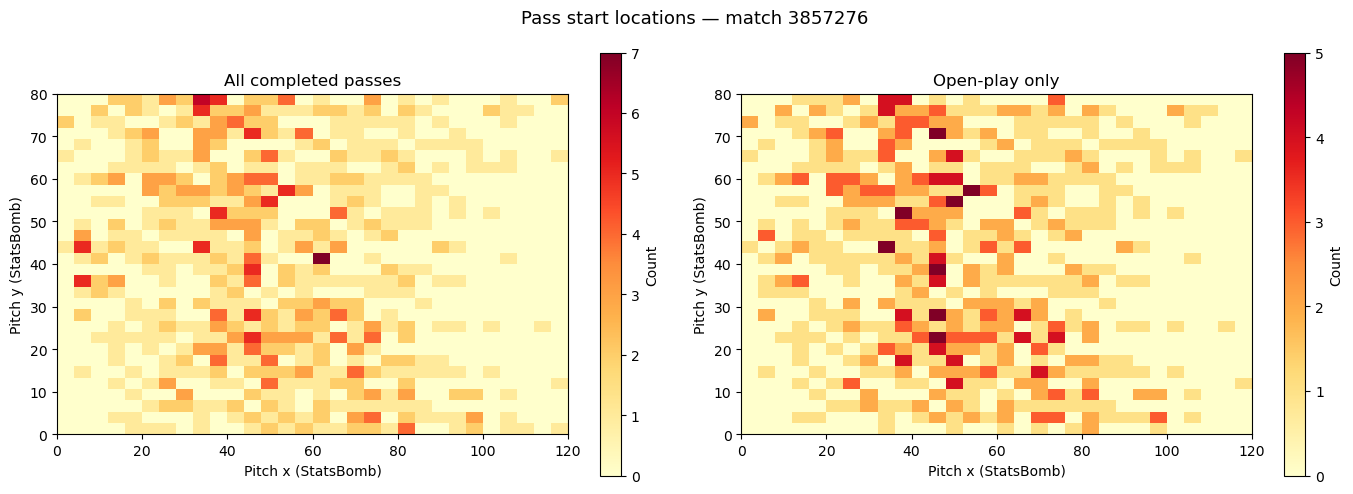

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label in zip(axes, [all_passes, op_passes],
                          ['All completed passes', 'Open-play only']):
    h = ax.hist2d(df['x'].dropna(), df['y'].dropna(),
                  bins=30, cmap='YlOrRd', range=[[0,120],[0,80]])
    plt.colorbar(h[3], ax=ax, label='Count')
    ax.set_xlabel('Pitch x (StatsBomb)')
    ax.set_ylabel('Pitch y (StatsBomb)')
    ax.set_title(label)
    ax.set_aspect('equal')

fig.suptitle(f'Pass start locations — match {sample_match_id}', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/01_pass_heatmap_sample.png', dpi=150, bbox_inches='tight')
plt.show()

### What this chart shows

- **Passing is heavily midfield-centric.** Both the "all passes" and "open-play only" heatmaps show a dense hot zone between x≈30–60 (central-to-attacking midfield), with the final third (x>80) and defensive third (x<20) both sparse — most of a team's passing volume never leaves the middle of the pitch.
- **Filtering out set pieces barely changes the shape.** The open-play-only panel looks almost identical to the all-passes panel, just with slightly lower counts — set pieces aren't distorting the spatial picture, so open-play filtering is mainly about isolating "flow" passes rather than reshaping where passes happen.

## 4b. Progressive vs non-progressive pass start locations

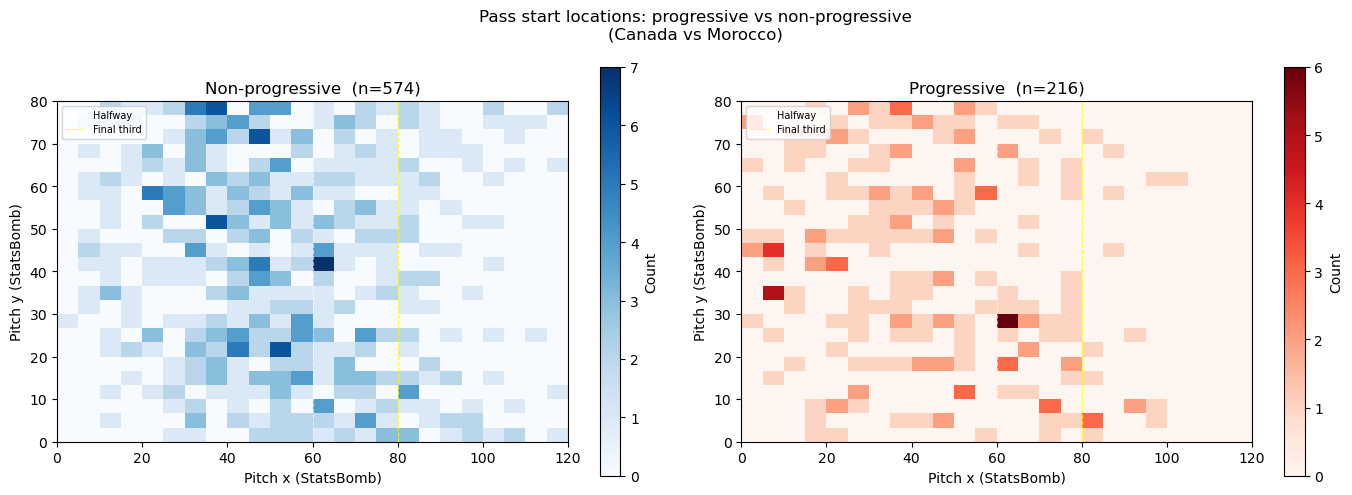

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

masks  = [~all_passes['is_progressive'], all_passes['is_progressive']]
labels = ['Non-progressive', 'Progressive']
cmaps  = ['Blues', 'Reds']

for ax, mask, label, cmap in zip(axes, masks, labels, cmaps):
    sub = all_passes[mask].dropna(subset=['x', 'y'])
    h = ax.hist2d(sub['x'], sub['y'], bins=24, cmap=cmap,
                  range=[[0, 120], [0, 80]])
    plt.colorbar(h[3], ax=ax, label='Count')
    ax.axvline(60, color='white', lw=0.8, ls='--', alpha=0.6, label='Halfway')
    ax.axvline(80, color='yellow', lw=0.8, ls='--', alpha=0.8, label='Final third')
    ax.set_xlabel('Pitch x (StatsBomb)')
    ax.set_ylabel('Pitch y (StatsBomb)')
    ax.set_title(f'{label}  (n={mask.sum()})')
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='upper left')

home = matches.loc[matches.match_id == sample_match_id, 'home_team'].values[0]
away = matches.loc[matches.match_id == sample_match_id, 'away_team'].values[0]
fig.suptitle(f'Pass start locations: progressive vs non-progressive\n({home} vs {away})', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/01_progressive_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### What this chart shows

- **Progressive passes are rarer and more spatially scattered than non-progressive ones.** Non-progressive passes (n=574) cluster tightly in a compact central-midfield band, while progressive passes (n=216) are spread thinner across the whole pitch — including deep in the defending third and out wide.
- **Progression doesn't come from one repeatable zone.** Unlike the concentrated non-progressive hot spot, the progressive heatmap has no single dominant cell — progressive passes look opportunistic, coming from wherever a forward passing lane opens up rather than a fixed build-up pattern.

## 5. Lineup / position data

In [13]:
lineups = load_lineups(sample_match_id)
print(f"Lineup rows: {len(lineups)}")
print(lineups[['player_name','team','position']].head(12).to_string(index=False))

Lineup rows: 52
          player_name    team                  position
       Sofiane Boufal Morocco                 Left Wing
    Abdelhamid Sabiri Morocco      Left Center Midfield
         Romain Saïss Morocco          Left Center Back
Munir Mohand Mohamedi Morocco                      None
       Sofyan Amrabat Morocco Center Defensive Midfield
         Hakim Ziyech Morocco                Right Wing
   Achraf Hakimi Mouh Morocco                Right Back
    Youssef En-Nesyri Morocco            Center Forward
       Yassine Bounou Morocco                Goalkeeper
       Jawad El Yamiq Morocco     Right Center Midfield
         Nayef Aguerd Morocco         Right Center Back
    Noussair Mazraoui Morocco                 Left Back


## 6. Summary statistics across all teams

In [14]:
# Quick pass-count summary per match — loads all 64 matches
# This cell can take 2-5 minutes; results are cached in data/raw/events/

rows = []
for _, mrow in matches.iterrows():
    mid = int(mrow['match_id'])
    try:
        ev = load_events(mid, cache_dir=RAW_DIR / 'events')
        ps = extract_passes(ev, open_play_only=False)
        for team in [mrow['home_team'], mrow['away_team']]:
            tp = ps[ps['team'] == team]
            rows.append({
                'match_id': mid,
                'team': team,
                'stage': mrow.get('stage_label', ''),
                'completed_passes': len(tp),
                'progressive_passes': int(tp['is_progressive'].sum()) if 'is_progressive' in tp else 0,
                'final_third': int(tp['is_final_third'].sum()) if 'is_final_third' in tp else 0,
                'reached_qf': int(team in QUARTERFINALISTS),
            })
    except Exception as e:
        print(f"  skip match {mid}: {e}")

summary = pd.DataFrame(rows)
summary.to_csv('../data/processed/pass_summary.csv', index=False)
print(f"Summary rows: {len(summary)}")
summary.head()

Summary rows: 128


,match_id,team,stage,completed_passes,progressive_passes,final_third,reached_qf
0,3857276,Canada,group,480,128,88,0
1,3857276,Morocco,group,310,88,47,1
2,3857271,England,group,746,191,143,1
3,3857271,Iran,group,163,49,40,0
4,3857296,Croatia,group,514,147,150,1


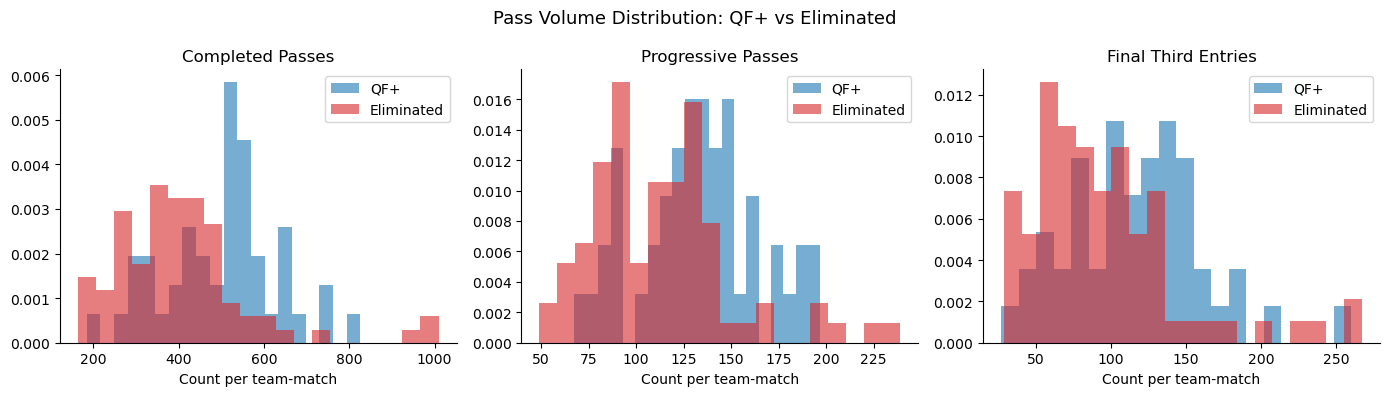

In [15]:
# Compare pass volume between QF teams and eliminated teams
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(
    axes,
    ['completed_passes', 'progressive_passes', 'final_third'],
    ['Completed Passes', 'Progressive Passes', 'Final Third Entries']
):
    for val, color, lbl in [(1, '#1f77b4', 'QF+'), (0, '#d62728', 'Eliminated')]:
        ax.hist(summary[summary['reached_qf']==val][col].dropna(),
                bins=20, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(label)
    ax.set_xlabel('Count per team-match')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Pass Volume Distribution: QF+ vs Eliminated', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/01_pass_volume_by_advancement.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("Mean pass stats by advancement group:")
summary.groupby('reached_qf')[['completed_passes','progressive_passes','final_third']].mean().round(1)

Mean pass stats by advancement group:


,completed_passes,progressive_passes,final_third
reached_qf,,,
0,403.7,112.4,94.8
1,501.0,132.3,116.4


## 6b. Pass length distribution — QF+ vs Eliminated

QF+           median=16.3m  mean=18.9m  Q25=11.2m  Q75=23.8m  n=24,050
Eliminated    median=17.3m  mean=19.8m  Q25=11.9m  Q75=24.7m  n=32,296


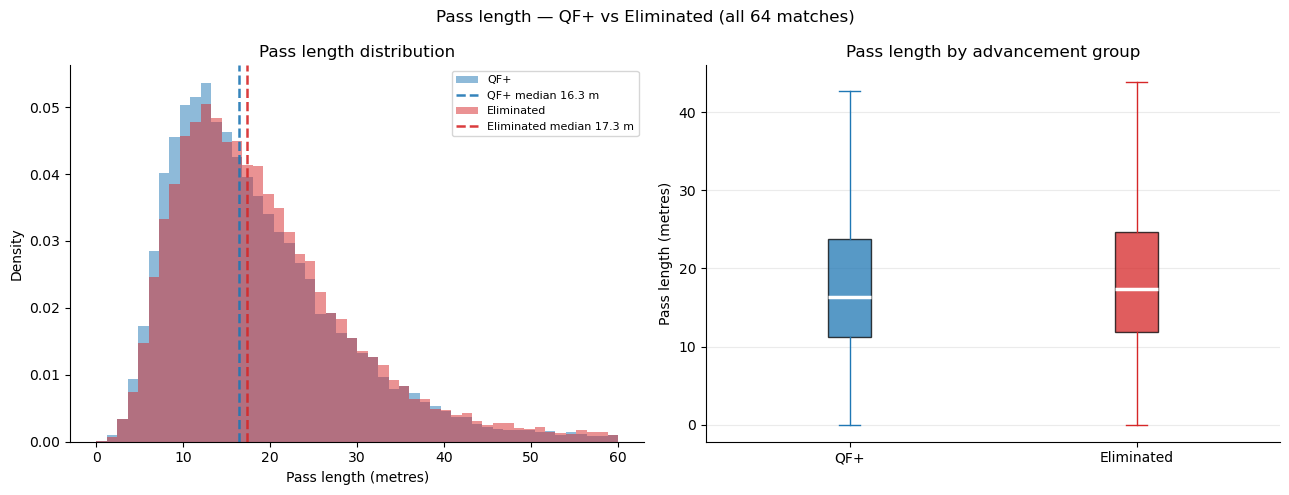

In [17]:
# Collect pass lengths across all 64 matches (reads from parquet cache)
length_rows = []
for _, mrow in matches.iterrows():
    mid = int(mrow['match_id'])
    try:
        ev = load_events(mid, cache_dir=RAW_DIR / 'events')
        passes = ev[(ev['type'] == 'Pass') & (ev['pass_outcome'].isna())]
        for team in [mrow['home_team'], mrow['away_team']]:
            tp = passes[passes['team'] == team]
            if 'pass_length' in tp.columns:
                for length in tp['pass_length'].dropna().values:
                    length_rows.append({
                        'pass_length': float(length),
                        'reached_qf': int(team in QUARTERFINALISTS),
                    })
    except Exception:
        pass

length_df = pd.DataFrame(length_rows)

# Summary stats
for val, lbl in [(1, 'QF+'), (0, 'Eliminated')]:
    v = length_df[length_df['reached_qf'] == val]['pass_length']
    print(f"{lbl:12s}  median={v.median():.1f}m  mean={v.mean():.1f}m  "
          f"Q25={v.quantile(0.25):.1f}m  Q75={v.quantile(0.75):.1f}m  n={len(v):,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — overlapping density histograms
ax = axes[0]
for val, color, lbl in [(1, '#1f77b4', 'QF+'), (0, '#d62728', 'Eliminated')]:
    vals = length_df[length_df['reached_qf'] == val]['pass_length']
    ax.hist(vals, bins=50, range=(0, 60), density=True,
            alpha=0.5, color=color, label=lbl)
    ax.axvline(vals.median(), color=color, lw=1.8, ls='--', alpha=0.9,
               label=f'{lbl} median {vals.median():.1f} m')
ax.set_xlabel('Pass length (metres)')
ax.set_ylabel('Density')
ax.set_title('Pass length distribution')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Right — box plot
ax = axes[1]
data   = [length_df[length_df['reached_qf'] == v]['pass_length'].values for v in [1, 0]]
colors = ['#1f77b4', '#d62728']
bp = ax.boxplot(data, labels=['QF+', 'Eliminated'], patch_artist=True,
                medianprops=dict(color='white', lw=2.5),
                showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for element in ['whiskers', 'caps']:
    for item, color in zip(bp[element], [c for c in colors for _ in range(2)]):
        item.set_color(color)
ax.set_ylabel('Pass length (metres)')
ax.set_title('Pass length by advancement group')
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Pass length — QF+ vs Eliminated (all 64 matches)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/01_pass_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### What this chart shows

The left panel shows the **distribution of individual pass lengths** (in metres) for every completed pass across all 64 matches — blue for QF+ teams, red for eliminated teams. The dashed lines mark each group's median. The right panel compares the two groups side by side as a box plot.

In simple terms: it shows whether better teams played shorter, sharper passes or longer, more direct balls.

---

### 3 key insights

**1. QF+ teams played shorter passes on average**
The QF+ median is **16.3 m** vs **17.3 m** for eliminated teams — about 1 metre shorter per pass. This is consistent across the entire distribution: the blue curve sits slightly to the left of the red. Shorter passing = more controlled, possession-based football rather than playing direct.

**2. Both groups use short passes most of the time**
The peak of both distributions sits around 10–20 m — these are the quick combinations in tight spaces that dominate modern football. Neither group relies heavily on long balls, but the eliminated teams have a slightly fatter right tail, meaning they hit more long passes (25 m+) than QF+ sides.

**3. This directly shapes what the passing networks will look like**
In notebook 02, QF+ team networks will tend to have more short, densely connected edges — many players linking with nearby teammates. Eliminated teams' networks will have longer edges and potentially fewer of them, reflecting a more direct style with fewer passing options.

## 7. Pass tempo by match minute

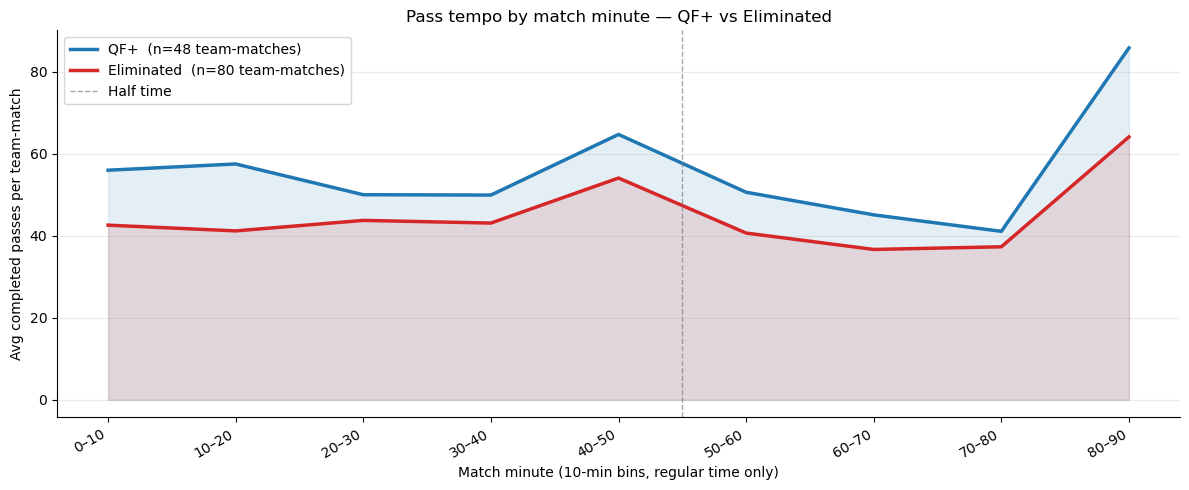

In [18]:
# Load minute-level pass data across all 64 matches (reads from parquet cache, fast)
time_rows = []
for _, mrow in matches.iterrows():
    mid = int(mrow['match_id'])
    try:
        ev = load_events(mid, cache_dir=RAW_DIR / 'events')
        ps = extract_passes(ev, open_play_only=False)
        for team in [mrow['home_team'], mrow['away_team']]:
            tp = ps[ps['team'] == team][['minute']].copy()
            tp['reached_qf'] = int(team in QUARTERFINALISTS)
            time_rows.append(tp)
    except Exception:
        pass

time_df = pd.concat(time_rows, ignore_index=True)

# Bin into 10-minute intervals, clip to 90 min (exclude extra time)
bin_edges  = list(range(0, 100, 10))
bin_labels = [f'{i}–{i+10}' for i in bin_edges[:-1]]
time_df['bin'] = pd.cut(time_df['minute'].clip(0, 89), bins=bin_edges,
                        right=False, labels=bin_labels)

n_qf   = summary[summary['reached_qf'] == 1].shape[0]
n_elim = summary[summary['reached_qf'] == 0].shape[0]

fig, ax = plt.subplots(figsize=(12, 5))
for val, color, lbl, n in [(1, '#1f77b4', 'QF+', n_qf),
                            (0, '#d62728', 'Eliminated', n_elim)]:
    counts = (time_df[time_df['reached_qf'] == val]
              .groupby('bin', observed=True).size() / n)
    x = np.arange(len(counts))
    ax.plot(x, counts.values, color=color, lw=2.5, label=f'{lbl}  (n={n} team-matches)')
    ax.fill_between(x, counts.values, alpha=0.12, color=color)

ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=30, ha='right')
ax.set_xlabel("Match minute (10-min bins, regular time only)")
ax.set_ylabel("Avg completed passes per team-match")
ax.set_title("Pass tempo by match minute — QF+ vs Eliminated")
ax.axvline(4.5, color='gray', ls='--', lw=1, alpha=0.7, label='Half time')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/01_time_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

### What this chart shows

Each line tracks the **average number of completed passes per 10-minute window** across all 64 World Cup matches — blue for teams that reached the quarter-finals (QF+), red for teams that were eliminated. The dashed line marks half time.

In simple terms: it shows *when* in a game each group of teams passes more.

---

### 3 key insights

**1. QF+ teams passed more in every single window**
The blue line is above the red line across the entire 90 minutes — not just in one period. Better teams didn't just dominate possession at one moment; they maintained a higher passing tempo throughout the whole match.

**2. The biggest gap is in the first 20 minutes (~13–16 extra passes)**
QF+ teams come out faster from kick-off and immediately take control of the ball. Eliminated teams never quite matched that early intensity. This suggests top teams set the tempo rather than react to the game.

**3. Both groups slow down in the 60–70 minute window**
Passing drops for everyone in this period — likely due to fatigue and teams becoming more cautious mid-second half. Interestingly the gap between the two groups is smallest here, meaning even good teams feel the pressure of this phase.

> ⚠️ **Note on the last bar (80–90):** The spike here is a data artefact — because we capped the minute column at 89, all second-half injury time passes (minute 90, 91, 92…) pile into this final bin, making it look artificially high. Don't read too much into it.

## 8. Pass volume by tournament stage

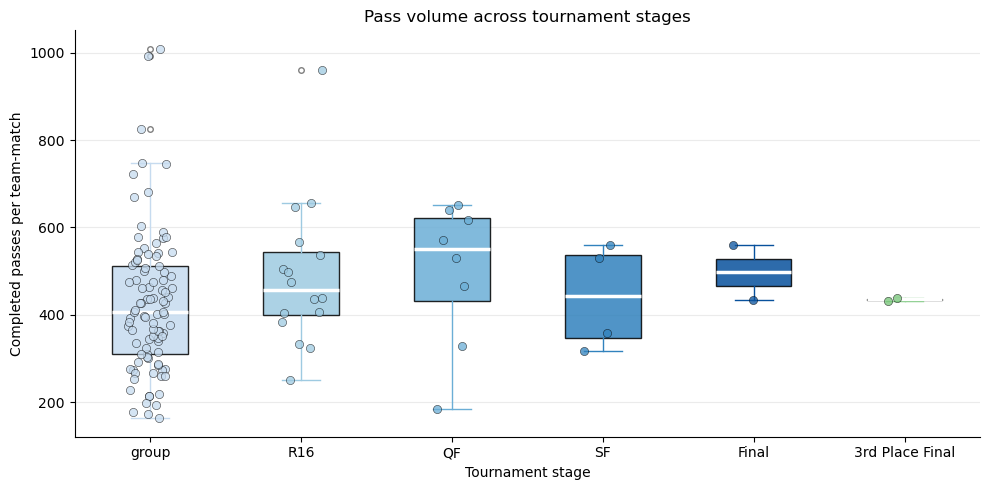


Median passes per team-match by stage:
  group                 median=406  n=96
  R16                   median=457  n=16
  QF                    median=552  n=8
  SF                    median=444  n=4
  Final                 median=497  n=2
  3rd Place Final       median=435  n=2


In [19]:
stage_order    = ['group', 'R16', 'QF', 'SF', 'Final', '3rd Place Final']
palette        = ['#c6dbef', '#9ecae1', '#6baed6', '#3182bd', '#08519c', '#74c476']

present_stages = [s for s in stage_order if s in summary['stage'].values]
data_by_stage  = [summary[summary['stage'] == s]['completed_passes'].dropna().values
                  for s in present_stages]
colors         = [palette[stage_order.index(s)] for s in present_stages]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_stage, labels=present_stages, patch_artist=True,
                medianprops=dict(color='white', lw=2.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for element in ['whiskers', 'caps']:
    for item, color in zip(bp[element], [c for c in colors for _ in range(2)]):
        item.set_color(color)
for flier, color in zip(bp['fliers'], colors):
    flier.set(marker='o', color=color, alpha=0.5, markersize=4)

# Individual data points
rng = np.random.default_rng(42)
for i, (stage_data, color) in enumerate(zip(data_by_stage, colors), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(stage_data))
    ax.scatter(i + jitter, stage_data, color=color, edgecolors='black',
               linewidths=0.4, s=35, alpha=0.75, zorder=3)

ax.set_xlabel('Tournament stage')
ax.set_ylabel('Completed passes per team-match')
ax.set_title('Pass volume across tournament stages')
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/01_pass_volume_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMedian passes per team-match by stage:")
for s in present_stages:
    vals = summary[summary['stage'] == s]['completed_passes']
    print(f"  {s:20s}  median={vals.median():.0f}  n={len(vals)}")

### What this chart shows

Each box shows the **spread of completed passes per team-match** at that stage of the tournament. The white line inside each box is the median. The dots are individual team-match observations — every dot is one team's pass count in one game.

In simple terms: it shows whether teams pass more or less as the tournament gets harder.

---

### 3 key insights

**1. Teams pass significantly more as they progress into the knockouts**
The median jumps from **406 in the group stage** to **457 in the R16** to a peak of **552 in the quarter-finals**. As weaker teams are eliminated, the remaining teams tend to dominate possession more — the games are played at a higher technical level.

**2. The quarter-finals had the highest passing volume of any round**
QF (median 552) is higher than even the semi-finals (444) and the Final (497). This suggests QF matches were the most open and possession-heavy — teams pressing hard to reach the semis, with less ultra-cautious defensive play than you see in a final.

**3. The spread shrinks as the tournament goes on**
In the group stage the boxes are wide — some teams completed fewer than 200 passes, others over 700. By the semis and final the dots are tightly clustered. This makes sense: only the most consistent, technically capable teams survive that far, so the variation narrows.

> ⚠️ **Note on SF, Final, and 3rd Place:** These stages have only n=4, 2, and 2 observations. The medians there are interesting but not statistically reliable — treat them as individual match snapshots, not a trend.

## Summary

- StatsBomb WC 2022 provides **64 matches** with full event-level data.
- Completed passes have **both passer and recipient** populated and **x/y start + end locations**.
- Set-piece passes constitute roughly 10–15% of completed passes; the open-play filter gives us a cleaner signal for tactical network analysis.
- Preliminary volume comparisons already suggest QF teams complete more passes per match — but volume alone is not the story; we need network structure in Notebook 02.

**Next:** Build directed passing networks for every (match_id, team) and engineer graph-theoretic features.